# EDA WhoOwns - Umfassende Bevölkerungs- & Eigentumsanalyse

Diese Vorlage analysiert die bereinigte Wohneigentums- und Bevölkerungsdaten aus `data/whoOwns/processed/`.

## Ziele dieser EDA:

- **Wohneigentumsquoten** nach Kanton analysieren und Trends erkennen
- **Bewohnertypen-Verteilung** visualisieren (Eigentümer, Mieter, etc.)
- **Wohnflächenverteilung** pro Person nach Bewohnertyp untersuchen
- **Regionale Unterschiede** identifizieren und darstellen

In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Project root with data/ folder not found.')

BASE_PATH = find_project_root(Path.cwd())

# Definiere alle Datenpfade (nur die verfügbaren Dateien)
WHONEIGENTUMSQUOTE_PROCESSED_PATH = BASE_PATH / 'data' / 'whoOwns' / 'processed' / 'wohneigentumsquote_kanton_2026_clean.csv'
WOHNFLAECHE_PROCESSED_PATH = BASE_PATH / 'data' / 'whoOwns' / 'processed' / 'bfs_wohnflaeche_20260414_clean.csv'
BEWOHNERTYP_PROCESSED_PATH = BASE_PATH / 'data' / 'whoOwns' / 'processed' / 'bfs_bewohnertyp_20260414_clean.csv'

# Lade Datenquellen
print("📊 Lade Datenquellen...")
wohneigentum = pd.read_csv(WHONEIGENTUMSQUOTE_PROCESSED_PATH)
wohnflaeche = pd.read_csv(WOHNFLAECHE_PROCESSED_PATH)
bewohnertyp = pd.read_csv(BEWOHNERTYP_PROCESSED_PATH)

# Standardisiere Spaltennamen
for df in [wohneigentum, wohnflaeche, bewohnertyp]:
    df.columns = df.columns.str.lower().str.strip()

print(f"✓ Wohneigentumsquote: {wohneigentum.shape}")
print(f"✓ Wohnflächenverteilung: {wohnflaeche.shape}")
print(f"✓ Bewohnertypen: {bewohnertyp.shape}")

📊 Lade Datenquellen...
✓ Wohneigentumsquote: (162, 5)
✓ Wohnflächenverteilung: (100, 3)
✓ Bewohnertypen: (340, 8)


In [31]:
# Datenübersicht und Explorative Statistiken
print("\n" + "="*70)
print("DATENÜBERSICHT: Wohneigentum-Daten (Kantonal)")
print("="*70)
print(f"\nDataset-Shape: {wohneigentum.shape[0]} Zeilen × {wohneigentum.shape[1]} Spalten")
print(f"\nVerfügbare Spalten:\n{list(wohneigentum.columns)}")
print(f"\nFehlende Werte:\n{wohneigentum.isnull().sum()[wohneigentum.isnull().sum() > 0]}")
print(f"\nDatentypen:\n{wohneigentum.dtypes}")

# Zeige Vorschau
print("\nVorschau (erste 5 Zeilen):")
wohneigentum.head()


DATENÜBERSICHT: Wohneigentum-Daten (Kantonal)

Dataset-Shape: 162 Zeilen × 5 Spalten

Verfügbare Spalten:
['time_period', 'geo', 'obs_value', 'obs_confidence', 'obs_status']

Fehlende Werte:
Series([], dtype: int64)

Datentypen:
time_period         int64
geo                object
obs_value         float64
obs_confidence    float64
obs_status         object
dtype: object

Vorschau (erste 5 Zeilen):


,time_period,geo,obs_value,obs_confidence,obs_status
0,2019,CH040,27.7,0.5,A
1,2019,CH021,38.8,0.6,A
2,2019,CH061,34.4,0.7,A
3,2019,CH062,42.9,3.5,A
4,2019,CH063,39.4,1.6,A


In [32]:
# Detaillierte Analyse der Bewohnertypen
print("\n" + "="*70)
print("BEWOHNERTYPEN-ANALYSE (BFS)")
print("="*70)
print(f"\nShape: {bewohnertyp.shape}")
print(f"\nSpalten: {list(bewohnertyp.columns)}")
print(f"\nFehlende Werte pro Spalte:")
print(bewohnertyp.isnull().sum())

print(f"\n📊 Beispieldaten:")
print(bewohnertyp.head(10).to_string())


BEWOHNERTYPEN-ANALYSE (BFS)

Shape: (340, 8)

Spalten: ['alter', 'bewohnertyp', 'absolute zahlen', 'vertrauens-intervall : \n± (in %)', 'anteil in %', 'vertrauens-\nintervall : \n± (in %-pkte)', 'datenqualität', 'sheet_type']

Fehlende Werte pro Spalte:
alter                                         0
bewohnertyp                                   0
absolute zahlen                               1
vertrauens-intervall : \n± (in %)             1
anteil in %                                   1
vertrauens-\nintervall : \n± (in %-pkte)     86
datenqualität                               321
sheet_type                                    0
dtype: int64

📊 Beispieldaten:
   alter                   bewohnertyp  absolute zahlen  vertrauens-intervall : \n± (in %)  anteil in %  vertrauens-\nintervall : \n± (in %-pkte) datenqualität   sheet_type
0     15  Mieter oder Genossenschafter          40110.0                                6.2         46.0                                       2.0           N

In [34]:
# Detaillierte Analyse der Wohnflächenverteilung
print("\n" + "="*70)
print("WOHNFLÄCHENVERTEILUNG (BFS)")
print("="*70)
print(f"\nShape: {wohnflaeche.shape}")
print(f"\nSpalten: {list(wohnflaeche.columns)}")
print(f"\nFehlende Werte pro Spalte:")
print(wohnflaeche.isnull().sum())

print(f"\n📊 Beispieldaten:")
print(wohnflaeche.head(10).to_string())


WOHNFLÄCHENVERTEILUNG (BFS)

Shape: (100, 3)

Spalten: ['alter', 'wohnfläche (in m2) pro person', 'sheet_type']

Fehlende Werte pro Spalte:
alter                            0
wohnfläche (in m2) pro person    0
sheet_type                       0
dtype: int64

📊 Beispieldaten:
   alter  wohnfläche (in m2) pro person   sheet_type
0      0                           27.6  wohnflaeche
1      1                           28.3  wohnflaeche
2      2                           28.2  wohnflaeche
3      3                           28.1  wohnflaeche
4      4                           27.9  wohnflaeche
5      5                           28.1  wohnflaeche
6      6                           28.2  wohnflaeche
7      7                           28.3  wohnflaeche
8      8                           28.5  wohnflaeche
9      9                           28.7  wohnflaeche



VISUALISIERUNGEN: WOHNEIGENTUMSQUOTEN NACH KANTON


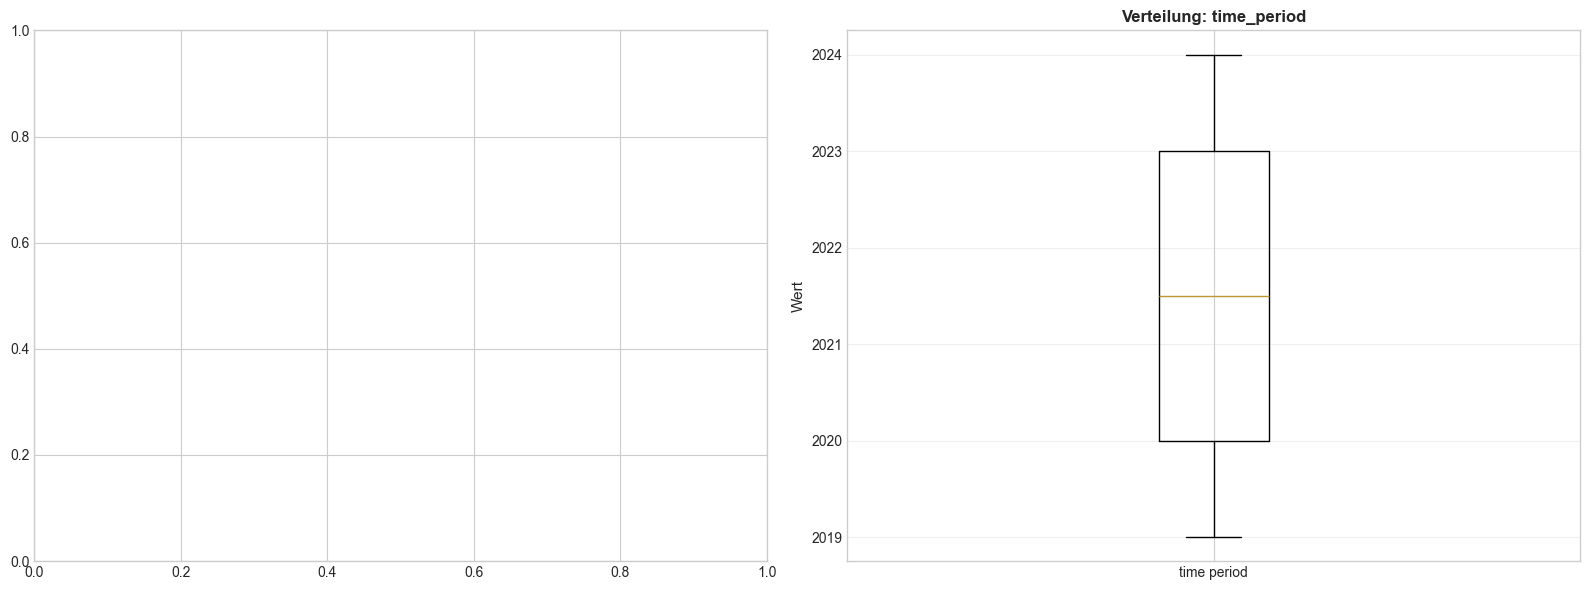

✓ Wohneigentum-Visualisierungen abgeschlossen


In [26]:
# Visualisierungen der Wohneigentum-Daten nach Kanton
print("\n" + "="*70)
print("VISUALISIERUNGEN: WOHNEIGENTUMSQUOTEN NACH KANTON")
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Finde numerische Spalten für Visualisierung
numeric_cols = wohneigentum.select_dtypes(include=[np.number]).columns.tolist()

# 1. Balkendiagramm: Wohneigentum nach Kanton
if 'kanton' in wohneigentum.columns.str.lower():
    kanton_col = [col for col in wohneigentum.columns if 'kanton' in col.lower()][0]
    # Finde beste numerische Spalte für Prozentsätze
    if len(numeric_cols) > 0:
        # Versuche eine Spalte zu finden, die wie Prozentzahl aussieht
        pct_cols = [col for col in numeric_cols if 'pct' in col.lower() or '%' in col.lower() or 'anteil' in col.lower()]
        if pct_cols:
            sort_col = pct_cols[0]
        else:
            sort_col = numeric_cols[0]
        
        sorted_data = wohneigentum.sort_values(sort_col, ascending=True, na_position='last')
        ax1.barh(sorted_data[kanton_col], sorted_data[sort_col], color='steelblue')
        ax1.set_xlabel(f'{sort_col} (%)', fontsize=11)
        ax1.set_ylabel('Kanton', fontsize=11)
        ax1.set_title('Wohneigentumsquoten nach Kanton', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='x')

# 2. Box-Plot: Verteilung numerischer Werte
if len(numeric_cols) > 0:
    for i, col in enumerate(numeric_cols[:1]):  # Zeige nur erste numerische Spalte
        bp = ax2.boxplot([wohneigentum[col].dropna()], labels=[col.replace('_', ' ')])
        ax2.set_ylabel('Wert', fontsize=11)
        ax2.set_title(f'Verteilung: {col}', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Wohneigentum-Visualisierungen abgeschlossen")


DETAILLIERTE BFS-VISUALISIERUNGEN


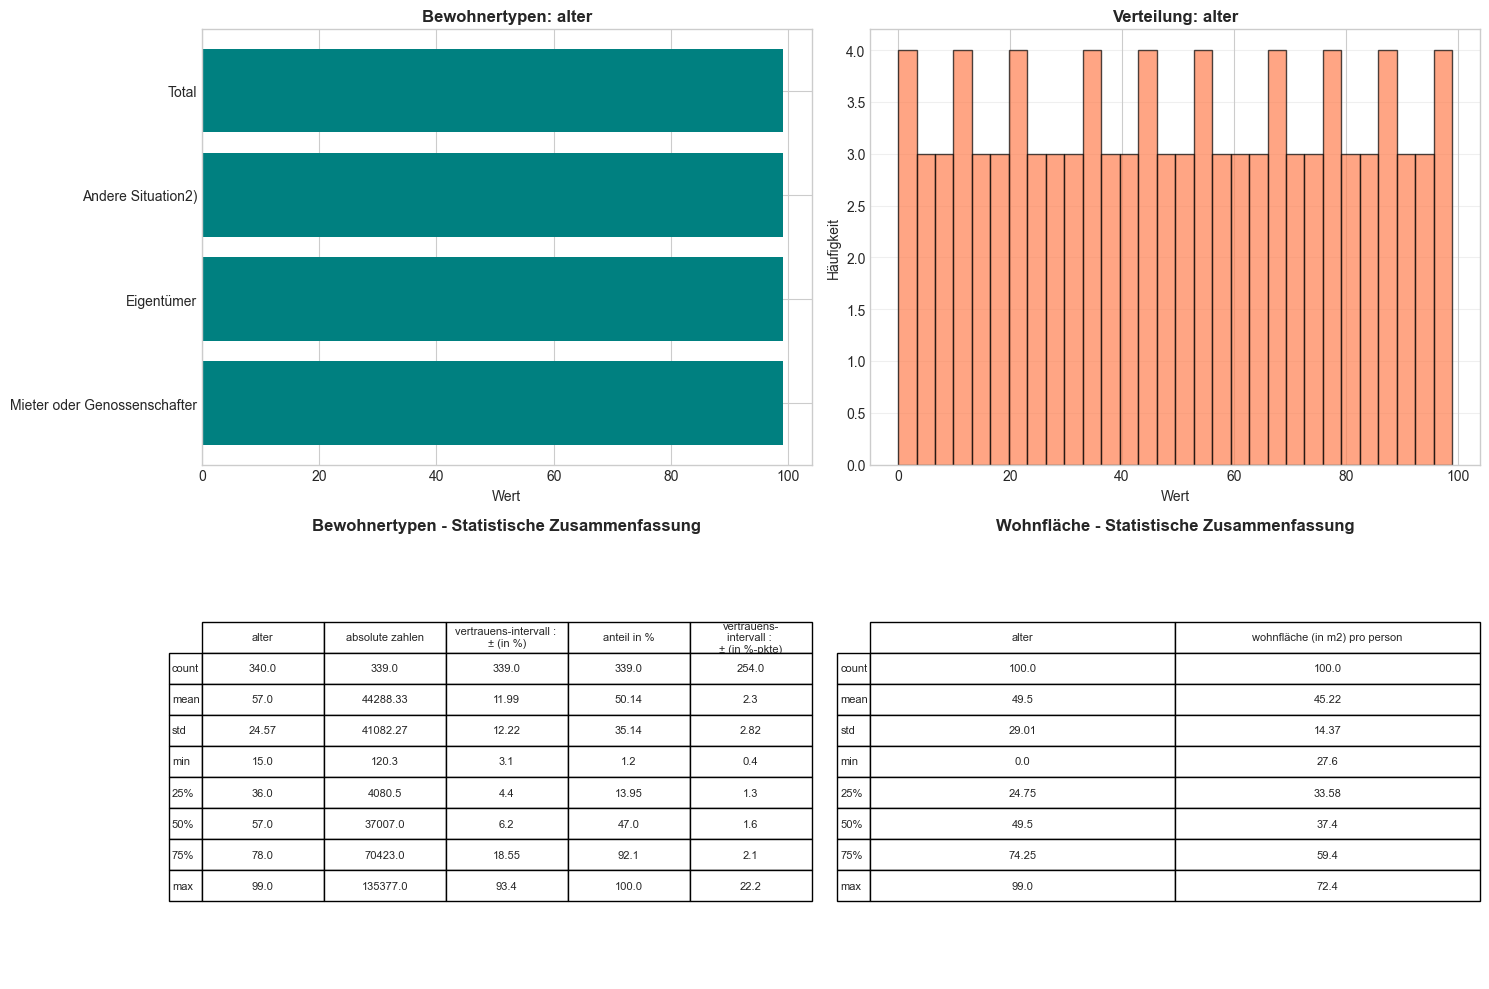

✓ BFS-Visualisierungen abgeschlossen


In [27]:
# Detaillierte BFS Visualisierungen: Bewohnertypen und Wohnfläche
print("\n" + "="*70)
print("DETAILLIERTE BFS-VISUALISIERUNGEN")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bewohnertypen - numerische Spalten
numeric_cols_bt = bewohnertyp.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols_bt) > 0:
    # Zeige Top Spalte für Bewohnertyp
    col_to_plot = numeric_cols_bt[0]
    bt_data = bewohnertyp[[col for col in bewohnertyp.columns if col.lower() in ['bewohnertyp', 'type', 'category']] + [col_to_plot]].dropna()
    
    if len(bt_data) > 0 and len(bt_data.columns) > 1:
        bt_data_sorted = bt_data.sort_values(col_to_plot, ascending=True)
        category_col = [col for col in bt_data.columns if col != col_to_plot][0]
        axes[0, 0].barh(bt_data_sorted[category_col].astype(str), bt_data_sorted[col_to_plot], color='teal')
        axes[0, 0].set_title(f'Bewohnertypen: {col_to_plot}', fontweight='bold')
        axes[0, 0].set_xlabel('Wert')
    else:
        # Fallback: Zeige Anzahl der Zeilen pro Spalte
        bewohnertyp_counts = bewohnertyp[numeric_cols_bt[0]].value_counts().head(10)
        axes[0, 0].barh(bewohnertyp_counts.index.astype(str), bewohnertyp_counts.values, color='teal')
        axes[0, 0].set_title('Top 10 Bewohnertypen-Werte', fontweight='bold')
        axes[0, 0].set_xlabel('Häufigkeit')
else:
    axes[0, 0].text(0.5, 0.5, 'Keine numerischen Spalten für Bewohnertyp', ha='center', va='center')
    axes[0, 0].set_title('Bewohnertypen', fontweight='bold')

# 2. Wohnflächenverteilung - Histogramm
numeric_cols_wf = wohnflaeche.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols_wf) > 0:
    wf_col = numeric_cols_wf[0]
    wf_data = wohnflaeche[wf_col].dropna()
    axes[0, 1].hist(wf_data, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title(f'Verteilung: {wf_col}', fontweight='bold')
    axes[0, 1].set_xlabel('Wert')
    axes[0, 1].set_ylabel('Häufigkeit')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
else:
    axes[0, 1].text(0.5, 0.5, 'Keine numerischen Spalten für Wohnfläche', ha='center', va='center')
    axes[0, 1].set_title('Wohnflächenverteilung', fontweight='bold')

# 3. Statistische Zusammenfassung - Bewohnertyp
axes[1, 0].axis('off')
if len(numeric_cols_bt) > 0:
    bt_stats = bewohnertyp[numeric_cols_bt].describe().round(2)
    table1 = axes[1, 0].table(cellText=bt_stats.values, 
                              rowLabels=bt_stats.index, 
                              colLabels=bt_stats.columns,
                              cellLoc='center', loc='center')
    table1.auto_set_font_size(False)
    table1.set_fontsize(8)
    table1.scale(1, 1.5)
    axes[1, 0].set_title('Bewohnertypen - Statistische Zusammenfassung', fontweight='bold', pad=10)
else:
    axes[1, 0].text(0.5, 0.5, 'Keine numerischen Daten', ha='center', va='center')

# 4. Statistische Zusammenfassung - Wohnfläche
axes[1, 1].axis('off')
if len(numeric_cols_wf) > 0:
    wf_stats = wohnflaeche[numeric_cols_wf].describe().round(2)
    table2 = axes[1, 1].table(cellText=wf_stats.values,
                              rowLabels=wf_stats.index,
                              colLabels=wf_stats.columns,
                              cellLoc='center', loc='center')
    table2.auto_set_font_size(False)
    table2.set_fontsize(8)
    table2.scale(1, 1.5)
    axes[1, 1].set_title('Wohnfläche - Statistische Zusammenfassung', fontweight='bold', pad=10)
else:
    axes[1, 1].text(0.5, 0.5, 'Keine numerischen Daten', ha='center', va='center')

plt.tight_layout()
plt.show()

print("✓ BFS-Visualisierungen abgeschlossen")


BFS DATENVISUALISIERUNGEN


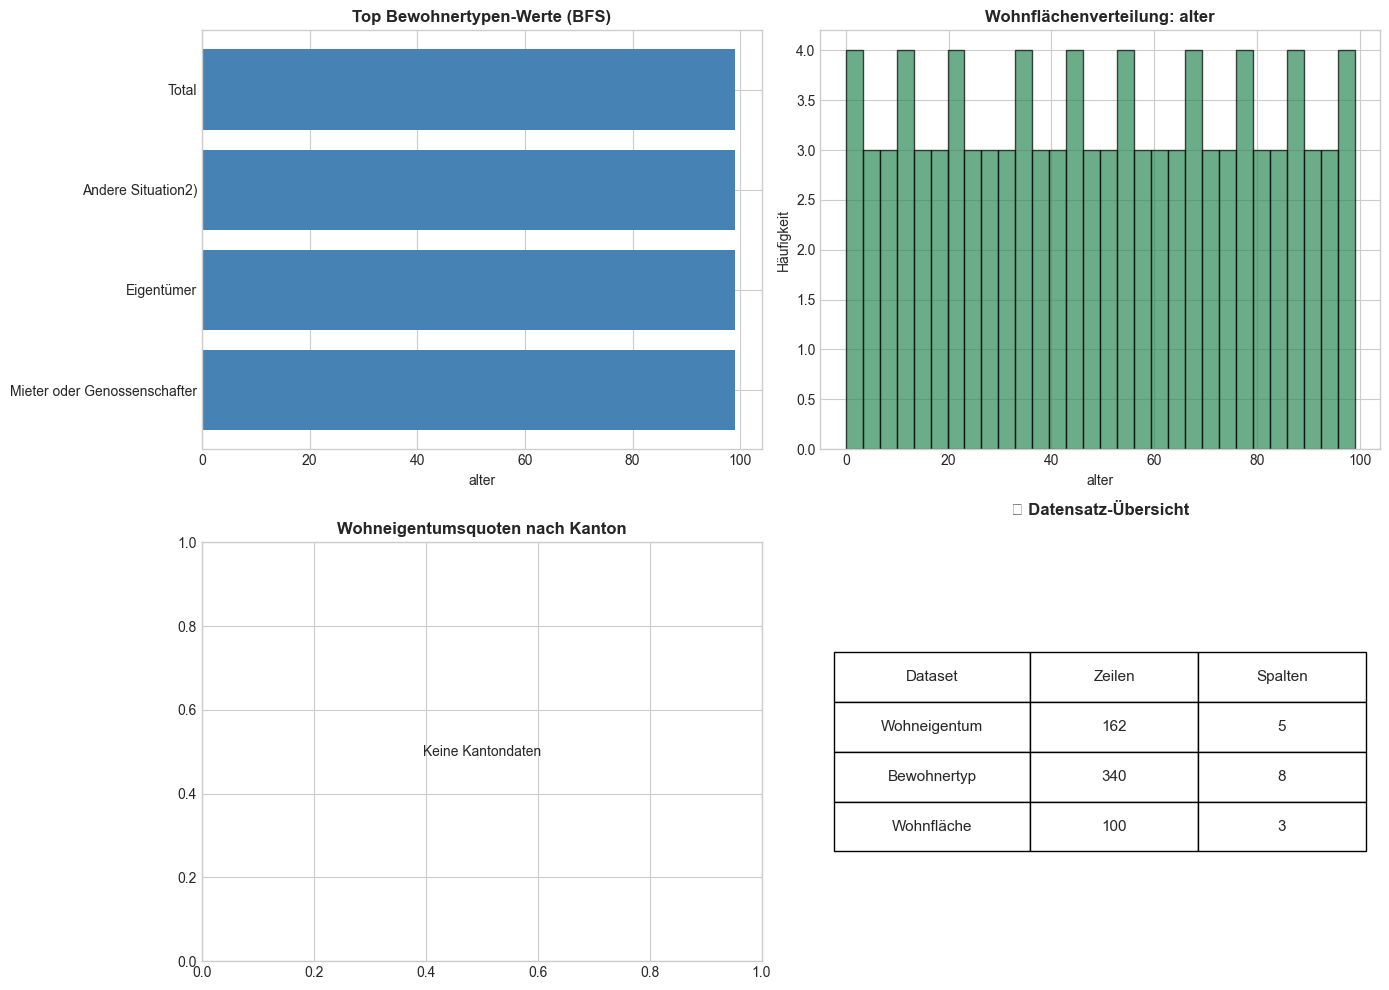


✓ BFS-Visualisierungen abgeschlossen


In [28]:
# Visualisierungen der BFS Daten
print("\n" + "="*70)
print("BFS DATENVISUALISIERUNGEN")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bewohnertypen Verteilung
numeric_cols_bt = bewohnertyp.select_dtypes(include=[np.number]).columns
if len(numeric_cols_bt) > 0:
    bt_col = numeric_cols_bt[0]
    bewohnertyp_top = bewohnertyp.nlargest(10, bt_col)
    # Versuche einen Label-Spalte zu finden
    label_cols = [col for col in bewohnertyp.columns if col.lower() in ['name', 'label', 'category', 'bewohnertyp', 'type']]
    if label_cols:
        label_col = label_cols[0]
        axes[0, 0].barh(bewohnertyp_top[label_col].astype(str), bewohnertyp_top[bt_col], color='steelblue')
        axes[0, 0].set_xlabel(f'{bt_col}')
    else:
        axes[0, 0].barh(range(len(bewohnertyp_top)), bewohnertyp_top[bt_col].values, color='steelblue')
        axes[0, 0].set_xlabel(f'{bt_col}')
else:
    axes[0, 0].text(0.5, 0.5, 'Keine numerischen Spalten', ha='center', va='center')
axes[0, 0].set_title('Top Bewohnertypen-Werte (BFS)', fontweight='bold')

# 2. Wohnflächenverteilung
numeric_cols_wf = wohnflaeche.select_dtypes(include=[np.number]).columns
if len(numeric_cols_wf) > 0:
    wf_col = numeric_cols_wf[0]
    wf_data = wohnflaeche[wf_col].dropna()
    axes[0, 1].hist(wf_data, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title(f'Wohnflächenverteilung: {wf_col}', fontweight='bold')
    axes[0, 1].set_xlabel(f'{wf_col}')
    axes[0, 1].set_ylabel('Häufigkeit')
else:
    axes[0, 1].text(0.5, 0.5, 'Keine numerischen Spalten', ha='center', va='center')
    axes[0, 1].set_title('Wohnflächenverteilung (BFS)', fontweight='bold')

# 3. Wohneigentumsquote nach Kanton
numeric_cols_we = wohneigentum.select_dtypes(include=[np.number]).columns
if len(numeric_cols_we) > 0 and 'kanton' in wohneigentum.columns.str.lower():
    kanton_col = [col for col in wohneigentum.columns if 'kanton' in col.lower()][0]
    we_col = numeric_cols_we[0]
    sorted_we = wohneigentum.sort_values(we_col, ascending=True, na_position='last').head(15)
    axes[1, 0].barh(sorted_we[kanton_col].astype(str), sorted_we[we_col], color='coral')
    axes[1, 0].set_xlabel(f'{we_col}')
    axes[1, 0].set_title('Wohneigentumsquoten (Bottom 15 Kantone)', fontweight='bold')
else:
    axes[1, 0].text(0.5, 0.5, 'Keine Kantondaten', ha='center', va='center')
    axes[1, 0].set_title('Wohneigentumsquoten nach Kanton', fontweight='bold')

# 4. Datensatz-Übersicht
summary_data = {
    'Dataset': ['Wohneigentum', 'Bewohnertyp', 'Wohnfläche'],
    'Zeilen': [wohneigentum.shape[0], bewohnertyp.shape[0], wohnflaeche.shape[0]],
    'Spalten': [wohneigentum.shape[1], bewohnertyp.shape[1], wohnflaeche.shape[1]]
}
summary_df = pd.DataFrame(summary_data)
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=summary_df.values, colLabels=summary_df.columns, 
                          cellLoc='center', loc='center', colWidths=[0.35, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)
axes[1, 1].set_title('📊 Datensatz-Übersicht', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✓ BFS-Visualisierungen abgeschlossen")

In [29]:
# Abschließende statistische Zusammenfassung und Erkenntnisse
print("\n" + "="*70)
print("STATISTISCHE ZUSAMMENFASSUNG - ALLE DATENSÄTZE")
print("="*70)

# 1. Wohneigentum Statistiken
print("\n📊 WOHNEIGENTUMSQUOTEN (Kantonal):")
print(f"   Anzahl Kantone: {wohneigentum.shape[0]}")
numeric_cols_we = wohneigentum.select_dtypes(include=[np.number]).columns
if len(numeric_cols_we) > 0:
    we_col = numeric_cols_we[0]
    print(f"   Spalte analysiert: {we_col}")
    print(f"   Min: {wohneigentum[we_col].min():.2f}")
    print(f"   Max: {wohneigentum[we_col].max():.2f}")
    print(f"   Mittelwert: {wohneigentum[we_col].mean():.2f}")
    print(f"   Median: {wohneigentum[we_col].median():.2f}")
    print(f"   Standardabweichung: {wohneigentum[we_col].std():.2f}")

# 2. Bewohnertypen Statistiken
print("\n👥 BEWOHNERTYPEN (BFS):")
print(f"   Datensatz-Größe: {bewohnertyp.shape}")
numeric_cols_bt = bewohnertyp.select_dtypes(include=[np.number]).columns
if len(numeric_cols_bt) > 0:
    print(f"   Numerische Spalten: {list(numeric_cols_bt)}")
    for col in numeric_cols_bt[:3]:  # Zeige max 3 Spalten
        print(f"   ├─ {col}:")
        print(f"      Mean: {bewohnertyp[col].mean():.2f}, Std: {bewohnertyp[col].std():.2f}")

# 3. Wohnflächenverteilung Statistiken
print("\n🏠 WOHNFLÄCHENVERTEILUNG (BFS):")
print(f"   Datensatz-Größe: {wohnflaeche.shape}")
numeric_cols_wf = wohnflaeche.select_dtypes(include=[np.number]).columns
if len(numeric_cols_wf) > 0:
    print(f"   Numerische Spalten: {list(numeric_cols_wf)}")
    for col in numeric_cols_wf[:3]:  # Zeige max 3 Spalten
        print(f"   ├─ {col}:")
        print(f"      Mean: {wohnflaeche[col].mean():.2f}, Std: {wohnflaeche[col].std():.2f}")

# 4. Gesamtzusammenfassung
print("\n" + "="*70)
print("✓ EDA abgeschlossen!")
print("="*70)
print("\nAnzahl Datensätze insgesamt:")
print(f"  • Wohneigentum: {wohneigentum.shape[0]} Kantone")
print(f"  • Bewohnertypen: {bewohnertyp.shape[0]} Einträge")
print(f"  • Wohnflächen: {wohnflaeche.shape[0]} Einträge")
print("\n💡 Nächste Schritte:")
print("  1. Weitere Datenquellen integrieren (z.B. Zeitreihendaten)")
print("  2. Regionale Vergleiche durchführen")
print("  3. Korrelationen zwischen Variablen analysieren")
print("  4. Interaktive Dashboards mit den Erkenntnissen erstellen")


STATISTISCHE ZUSAMMENFASSUNG - ALLE DATENSÄTZE

📊 WOHNEIGENTUMSQUOTEN (Kantonal):
   Anzahl Kantone: 162
   Spalte analysiert: time_period
   Min: 2019.00
   Max: 2024.00
   Mittelwert: 2021.50
   Median: 2021.50
   Standardabweichung: 1.71

👥 BEWOHNERTYPEN (BFS):
   Datensatz-Größe: (340, 8)
   Numerische Spalten: ['alter', 'absolute zahlen', 'vertrauens-intervall : \n± (in %)', 'anteil in %', 'vertrauens-\nintervall : \n± (in %-pkte)']
   ├─ alter:
      Mean: 57.00, Std: 24.57
   ├─ absolute zahlen:
      Mean: 44288.33, Std: 41082.27
   ├─ vertrauens-intervall : 
± (in %):
      Mean: 11.99, Std: 12.22

🏠 WOHNFLÄCHENVERTEILUNG (BFS):
   Datensatz-Größe: (100, 3)
   Numerische Spalten: ['alter', 'wohnfläche (in m2) pro person']
   ├─ alter:
      Mean: 49.50, Std: 29.01
   ├─ wohnfläche (in m2) pro person:
      Mean: 45.22, Std: 14.37

✓ EDA abgeschlossen!

Anzahl Datensätze insgesamt:
  • Wohneigentum: 162 Kantone
  • Bewohnertypen: 340 Einträge
  • Wohnflächen: 100 Einträge

💡 N